<a href="https://colab.research.google.com/github/poojabongale/Brain-Tumor-MRI-Classification-/blob/main/Brain_tumor_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Brain Tumor MRI Classification**
A Machine learning project that uses concepts of deep learning to predict tumor. The tumor belongs to 4 classes : glioma,pitutary, meningioma and no tumor. This project helps in classifying the images into these 4 classess with confidence score and accuracy.
This project leverages MobileNet V2 model which is based on convolutional neural networks. This model typically extracts features from grid like datasets and is mainly for visuals like image and video processing.
MobileNetV2 is widely used for tasks like image classification, object detection, and semantic segmentation

Importing and Installing Libraries

os : Handles files and directories and to specify image paths for loading

numpy : to handle mathematical functions, multi-dimensional arrays

matplotlib : to visualize the data

tensorflow.keras.preprocessing.image : it automatically augments the image, loads it from directories and feeds it to the model during training

tensorflow.keras.applications.MobileNetV2 : A lightweight, pre-trained deep learning model from Keras Applications. Used as the base model for transfer learning to extract features from MRI images, reducing training time and improving performance.

tensorflow.keras.models : Helps in building a custom base model

Sequential: stack layers in order, easiest way to build models.

Conv2D: Helps in preprocessing images in grid like structures and detects image features (edges, textures).

Flatten: Converts 2D feature maps into 1D vectors for dense layers.

Dense: Fully connected layers for decision making.

Dropout: Randomly drops neurons to prevent overfitting.

BatchNormalization: Stabilizes and accelerates training by normalizing activations.

EarlyStopping, ModelCheckpoint: Helps monitor model performance and save the best version.

In [1]:
!pip install -q tensorflow

In [2]:
import os, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


# **DataSet Link**
https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

# **Github Link**

# **Loading the dataset from drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#Splitting the dataset into trainig and testing
train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'


In [5]:
#definig class labels
class_labels = ['glioma', 'meningioma', 'pituitary', 'no_tumor']


In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32 #Each batch has 32 images for training and testing

#ImageDataGenerator is trying to modify the original images to generate new data
#This is our training dataset
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
).flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical',
    batch_size=BATCH_SIZE
)
#this is testing dataset that is only rescaled/normalized
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5741 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


# **Histogram Plot**
A plot that shows the distribution of tumors over the dataset. Dataset has maximum no_tumor class images followed by pitutary and meningioma and glioma are very close to each other interms of count.

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


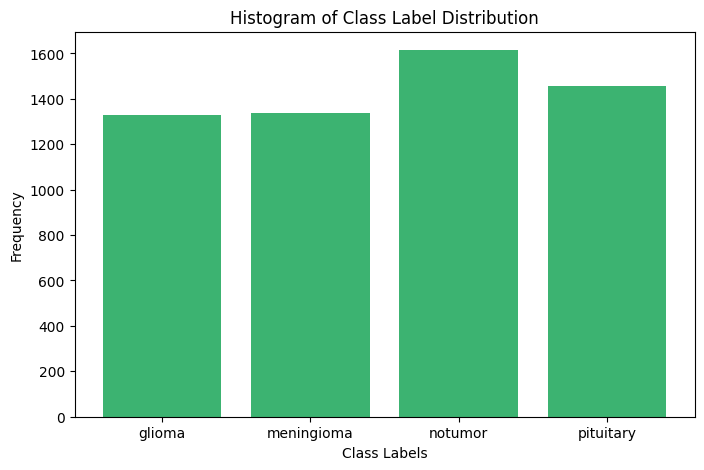

In [7]:
from collections import Counter

#Get class indices mapping (e.g., {'tumor': 0, 'no_tumor': 1})
class_indices = train_gen.class_indices
print("Class indices:", class_indices)

#Convert class indice to labels
labels = list(class_indices.keys())

class_labels = train_gen.classes
num_classes = len(class_labels)

#Count frequency of each class
class_counts = Counter(class_labels)

x = [labels[i] for i in class_counts.keys()]
y = [class_counts[i] for i in class_counts.keys()]

#Plot histogram
plt.figure(figsize=(8,5))
plt.bar(x, y, color='mediumseagreen')
plt.xlabel('Class Labels')
plt.ylabel('Frequency')
plt.title('Histogram of Class Label Distribution')
plt.show()


In [8]:
class_labels = train_gen.class_indices
num_classes = len(class_labels)

In [9]:
#This code helps in calculation class weights for each class to handle imbalance
labels = train_gen.classes #numpy array that consists of class indices
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))


In [10]:
#here the model is trained using MobileNetV2 where wieghts are taken from imagenet, the top layer from MobileNetV2 is skipped and input shape is provided
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x) #Here 128 neurons forms dense layers
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
print("Class indices (used in training):", train_gen.class_indices)


Class indices (used in training): {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Callbacks : tool to help in training

EarlyStopping : stops the training if the loss on testing data does not improves

ModelCheckpoint: a point at which model is saved when the model is performing well

In [25]:
import random
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('model.h5', save_best_only=True)
]
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seeds()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7690 - loss: 0.6015

180/180 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.7695 - loss: 0.6003 - val_accuracy: 0.5324 - val_loss: 1.8927
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9400 - loss: 0.1745

180/180 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9400 - loss: 0.1745 - val_accuracy: 0.6712 - val_loss: 1.0278
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9506 - loss: 0.1421 - val_accuracy: 0.6018 - val_loss: 1.5446
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9652 - loss: 0.1034

180/180 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.9652 - loss: 0.1034 - val_accuracy: 0.7735 - val_loss: 0.6925
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9724 - loss: 0.0777 - val_accuracy: 0.7178 - val_loss: 1.0090


In [ ]:
model.save('model.keras')
print("✅ Model saved as model.keras")

✅ Model saved as model.keras


# **Plots for Accuracy and Loss**
The plot shows the accuracy for training and testing data over each iteration. For the accuracy plot the curve is increasing that means the model is learning well from the data and the loss plot is also good because the errors in the model are decreasing.

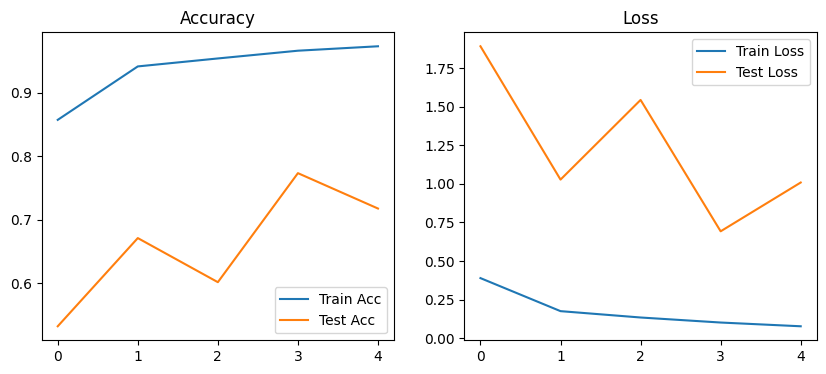

In [26]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Test Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title('Loss')
plt.show()

# **Classification Report**

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels
true_classes = val_gen.classes
class_indices = val_gen.class_indices
class_labels = list(class_indices.keys())

# Predict on validation generator
val_gen.reset()
pred_probs = model.predict(val_gen, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))



41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 477ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.54      0.99      0.70       300
  meningioma       0.97      0.58      0.73       306
     notumor       0.92      0.93      0.92       405
   pituitary       0.95      0.54      0.69       300

    accuracy                           0.77      1311
   macro avg       0.85      0.76      0.76      1311
weighted avg       0.85      0.77      0.77      1311



# **Confusion Matrix**
This metric helps is understanding the values of predicted classes vs true classes. Here on x-xis we have predicted classes and on y-axis,true classes.
For glioma predicted, 290 are actual true glioma classes i.e 295 images were correctly predicted and of the others predicted as glioma which belonged to other classes meningioma(83), no_tumor(25), pitutary(66).
So this plot helps in understanding the predictions vs the reality

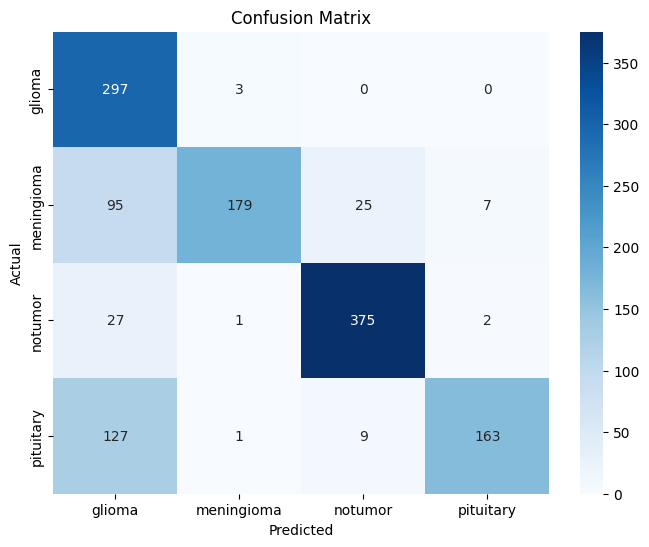

In [28]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# **Custom CNN Model**

Define the custom CNN model and later create sequential layers for data flow using sequential of tensorflow



In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
IMG_SIZE = 128
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = 4

custom_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    # Dense Layers
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Compile the model**


Callbacks : tool to help in training, they are functions automatically executing during the phase of training. It can be functioning at the start or end of epoch.

EarlyStopping : stops the training if the loss on testing data does not improves

ModelCheckpoint: a point at which model is saved when the model is performing well

In [13]:
custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_custom_cnn_model.h5', save_best_only=True, monitor='val_loss')
]

In the following block, data augmentation is done i.e image is being edited. It is rescales, rotated by 15 degrees, shifted to left/right in width by 10%, shifted up/down in height by 10%, horizontally flipped. Then the images are fetched from the respective folders.
Testing data has only been rescales and not augmented because the testing shuld take place on clean and unmodified data. Similarly path is specified for testing data and shuffle = True so that at each epoch the images are shuffled.

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to your training and validation image directories
train_dir = '/content/drive/MyDrive/MRI Images/Training'
test_dir = '/content/drive/MyDrive/MRI Images/Testing'

# Image preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalize pixel values
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 5741 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


Weights : Calculates the strenght of connection between  neurons. It helps in understanding the influence of one neuron on another .

In [15]:
labels = train_gen.classes  # This gives an array of class indices
class_labels = list(train_gen.class_indices.keys())  # Optional: to map index → class name
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights_array))


In [17]:
history_custom = custom_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,  # increase this
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8054 - loss: 0.5278

180/180 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.8054 - loss: 0.5277 - val_accuracy: 0.6453 - val_loss: 1.3765
Epoch 2/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.8120 - loss: 0.5125 - val_accuracy: 0.5614 - val_loss: 1.3791
Epoch 3/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7954 - loss: 0.5427

180/180 ━━━━━━━━━━━━━━━━━━━━ 424s 2s/step - accuracy: 0.7954 - loss: 0.5425 - val_accuracy: 0.7796 - val_loss: 0.6378
Epoch 4/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.8334 - loss: 0.4444 - val_accuracy: 0.7223 - val_loss: 0.9253
Epoch 5/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.8445 - loss: 0.4164 - val_accuracy: 0.7285 - val_loss: 0.9483
Epoch 6/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.8645 - loss: 0.3865 - val_accuracy: 0.5225 - val_loss: 4.2335
Epoch 7/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.8692 - loss: 0.3607 - val_accuracy: 0.5461 - val_loss: 2.2533
Epoch 8/8
180/180 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.8521 - loss: 0.3884 - val_accuracy: 0.6323 - val_loss: 1.4696


# **Set up call backs**
Callbacks : tool to help in training

EarlyStopping : stops the training if the loss on testing data does not improves

ModelCheckpoint: a point at which model is saved when the model is performing well

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_custom_cnn_model.h5', save_best_only=True, monitor='val_loss')
]


# **Train Model**

In [ ]:
history_custom = custom_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks,
    class_weight=class_weights,  # only if using class weights
    verbose=1
)


Epoch 1/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6100 - loss: 1.1254

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


180/180 ━━━━━━━━━━━━━━━━━━━━ 2082s 12s/step - accuracy: 0.6104 - loss: 1.1241 - val_accuracy: 0.2288 - val_loss: 26.8210
Epoch 2/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7408 - loss: 0.6819

180/180 ━━━━━━━━━━━━━━━━━━━━ 458s 3s/step - accuracy: 0.7409 - loss: 0.6819 - val_accuracy: 0.2540 - val_loss: 16.2409
Epoch 3/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7886 - loss: 0.5824

180/180 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.7886 - loss: 0.5824 - val_accuracy: 0.4813 - val_loss: 2.0921
Epoch 4/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8023 - loss: 0.5324

180/180 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.8023 - loss: 0.5324 - val_accuracy: 0.7719 - val_loss: 0.7096
Epoch 5/5
180/180 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.8191 - loss: 0.4865 - val_accuracy: 0.7124 - val_loss: 1.3171


In [19]:
loss, accuracy = custom_cnn.evaluate(val_gen, verbose=1)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 456ms/step - accuracy: 0.7376 - loss: 0.7700
Validation Loss: 0.6378
Validation Accuracy: 77.96%


# **Plot for Accuarcy and Loss**

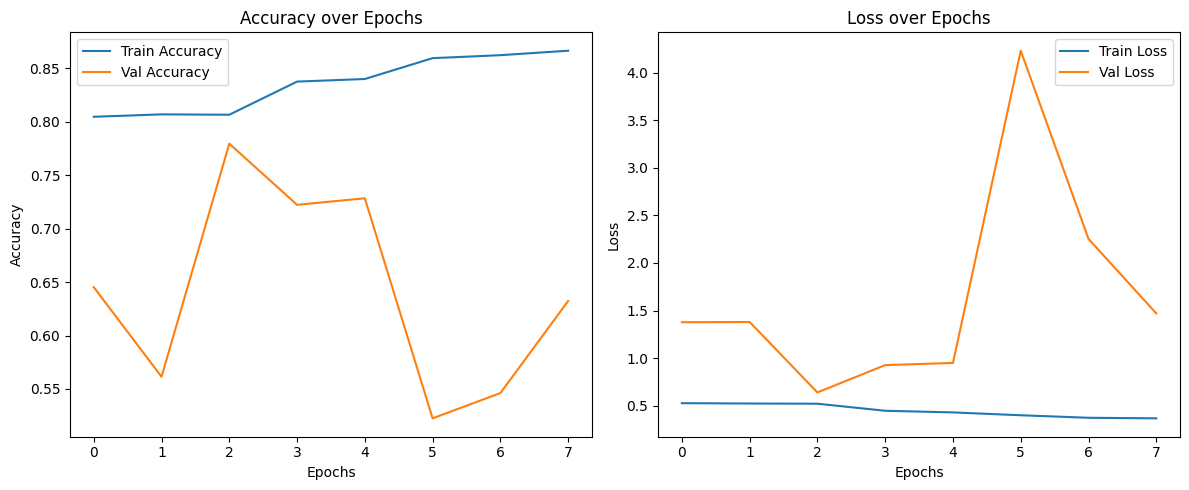

In [20]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['accuracy'], label='Train Accuracy')
plt.plot(history_custom.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_custom.history['loss'], label='Train Loss')
plt.plot(history_custom.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In the accuracy plot the accuracy for training and validation is increasing over the iterations and for loss plot the loss is decreasing over each epoch which is a good sign

In [ ]:
# Get ground truth labels and predicted probabilities
y_true = val_gen.classes
y_pred_probs = custom_cnn.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)


41/41 ━━━━━━━━━━━━━━━━━━━━ 23s 562ms/step


# **Classification report and Confusion Matrix**

41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 462ms/step
              precision    recall  f1-score   support

      glioma       0.73      0.86      0.79       300
  meningioma       0.82      0.31      0.45       306
     notumor       0.76      0.99      0.86       405
   pituitary       0.86      0.89      0.87       300

    accuracy                           0.78      1311
   macro avg       0.79      0.76      0.74      1311
weighted avg       0.79      0.78      0.75      1311



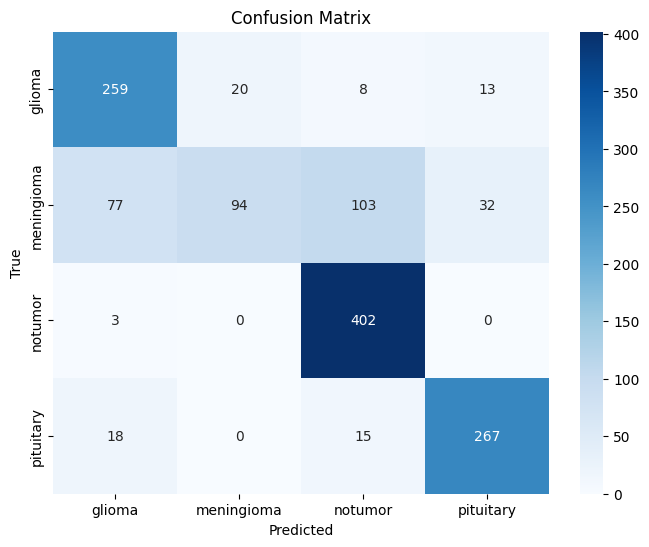

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get ground truth labels and predicted probabilities
y_true = val_gen.classes
y_pred_probs = custom_cnn.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print classification report
target_names = list(val_gen.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Comparison between Custom CNN vs MobileNetV2**

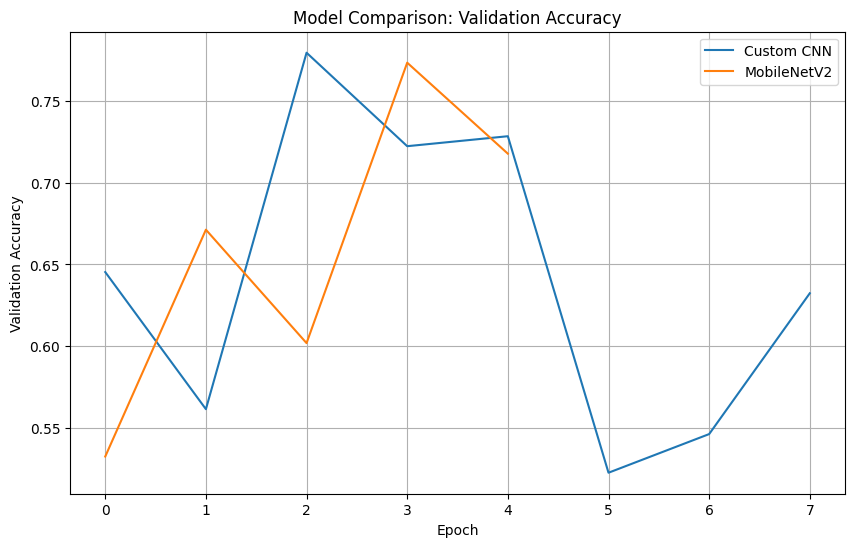

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_custom.history['val_accuracy'], label='Custom CNN')
#plt.plot(history.history['val_accuracy'], label='MobileNet V2')

# Check if history for MobileNetV2 exists before plotting
if 'history' in locals():
    plt.plot(history.history['val_accuracy'], label='MobileNetV2')
else:
    print("MobileNetV2 training history not found. Please run the MobileNetV2 training cell (zclySPOYffci) first.")

plt.title('Model Comparison: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

As we can see in the graph , in the intial epochs upto 2 the accuracy was rising and falling but after that it kept on increasing for both the models. For MobileNetV2 model there were 5 epochs but it has stopped at 5 because of EarlyStopping and same goes with Custom CNN model it has 8 epochs but it stopped at 7.